In [1]:
#Load in a bunch of useful functions:

import numpy as np
import matplotlib.pyplot as plt
from importlib import reload

import Detectors.Deep_Learning.AutoEncoders.utils
reload(Detectors.Deep_Learning.AutoEncoders.utils)
from Detectors.Deep_Learning.AutoEncoders.utils import SeqDataset,train_epoch,eval_data,train_model

# import flow.visualize.visualize_ring as visualize_ring
# reload(visualize_ring)
# from flow.visualize.visualize_ring import get_measured_leader,get_rel_dist_to_measured_leader,get_vel_of_measured_leader



import torch

# Anti-Flow specific functions for  detection:

from Detectors.Deep_Learning.AutoEncoders.utils import sliding_window
from Detectors.Deep_Learning.AutoEncoders.cnn_lstm_ae import CNNRecurrentAutoencoder

import utils
reload(utils)
from utils import Bando_OVM_FTL

import os

print('Libraries loaded.')


import Adversaries.controllers.car_following_adversarial
from Adversaries.controllers.car_following_adversarial import FollowerStopper_Overreact
from Adversaries.controllers.car_following_adversarial import ACC_Benign


import time

from Detectors.Deep_Learning.AutoEncoders.utils import SeqDataset,train_epoch,eval_data,train_model,get_cnn_lstm_ae_model,make_train_X,sliding_window_mult_feat

from Detectors.Deep_Learning.AutoEncoders.utils import get_loss_filter_indiv as loss_smooth

import flow.visualize.visualize_ring as visualize_ring

from flow.visualize.visualize_ring import get_measured_leader,get_rel_dist_to_measured_leader,get_vel_of_measured_leader

from copy import deepcopy

import sys


print('Imported detection tools.')

Libraries loaded.
Imported detection tools.


In [2]:
ARED_data_path = '/Users/vanderbilt/Desktop/Research_2021/ARED-Model-Calibration/'

T_vals = np.loadtxt(ARED_data_path+'vehT.csv').T
V_vals = np.loadtxt(ARED_data_path+'vehV.csv').T
S_vals = np.loadtxt(ARED_data_path+'vehS.csv').T
VL_vals = np.loadtxt(ARED_data_path+'vehVL.csv').T
X_vals = np.loadtxt(ARED_data_path+'vehX.csv').T


print('ARED data loaded in.')

ARED data loaded in.


In [3]:
FIGURE_SIZE = [35,10]
TITLE_FONTSIZE = 40
LABEL_FONTSIZE = 40
TICK_FONTSIZE = 35

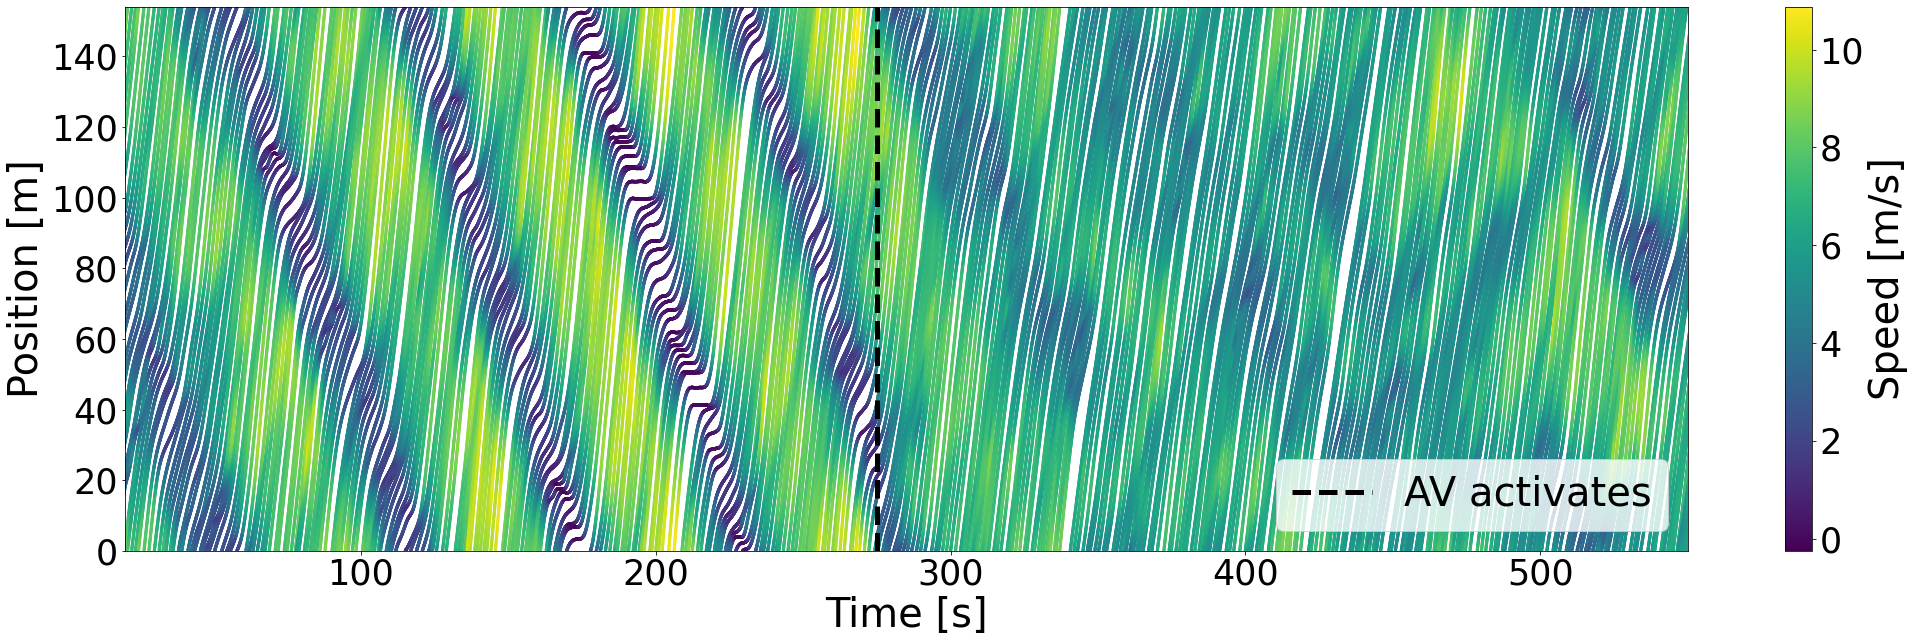

In [9]:
ring_length_effective = 153.9 #Amount of free space when car lengths are taken out

train_begin = 600
train_end = 275*30
 
V_train = V_vals[train_begin:train_end,:]
S_train = S_vals[train_begin:train_end,:]
VL_train = VL_vals[train_begin:train_end,:]
T_train = T_vals[train_begin:train_end,:]
X_train = X_vals[train_begin:train_end,:]

test_begin = 275*30
test_end = 550*30
 
V_test = V_vals[test_begin:test_end,:]
S_test = S_vals[test_begin:test_end,:]
VL_test = VL_vals[test_begin:test_end,:]
T_test = T_vals[test_begin:test_end,:]
X_test = X_vals[test_begin:test_end,:]


fig = plt.figure(figsize=FIGURE_SIZE)

plt.scatter(T_vals,np.mod(X_vals,ring_length_effective),s=5,c=V_vals)
plt.plot([275,275],[0,ring_length_effective],'k--',linewidth=5.0,label='AV activates')
plt.legend(fontsize=LABEL_FONTSIZE,loc='lower right')
plt.xlim([20,550])
plt.ylim([0,ring_length_effective])
plt.ylabel('Position [m]',fontsize=LABEL_FONTSIZE)
plt.xlabel('Time [s]',fontsize=LABEL_FONTSIZE)
plt.xticks(fontsize=TICK_FONTSIZE)
plt.yticks(fontsize=TICK_FONTSIZE)
cb = plt.colorbar()
cb.set_label(label='Speed [m/s]',size=LABEL_FONTSIZE)
for t in cb.ax.get_yticklabels():
     t.set_fontsize(TICK_FONTSIZE)

plt.savefig("ARED_data_spacetime.png",bbox_inches='tight')

print('Saved figure.')

In [11]:
from scipy.interpolate import interp1d

V_train = V_vals[train_begin:train_end,:]
S_train = S_vals[train_begin:train_end,:]
VL_train = VL_vals[train_begin:train_end,:]
T_train = T_vals[train_begin:train_end,:]
X_train = X_vals[train_begin:train_end,:]

V_train_resampled = []
S_train_resampled = []
T_train_resampled = []
X_train_resampled = []

veh_ids = range(21)

timeseries_dict_train = dict.fromkeys(veh_ids)

for veh_id in veh_ids:
    times = T_train[:,veh_id]
    speeds = V_train[:,veh_id]
    spacings = S_train[:,veh_id]
    lead_speeds = VL_train[:,veh_id]
    rel_vel = lead_speeds - speeds
    
    # resample everything to be at 10 herz so it works with detection hyper parameters:
    
    resampled_times = np.arange(times[0],times[-1],0.1)
    T_train_resampled.append(resampled_times)
    #speed
    speed_interp = interp1d(times, speeds, kind='cubic')
    resampled_speeds = speed_interp(resampled_times)
    V_train_resampled.append(resampled_speeds)
    #spacing
    spacing_interp = interp1d(times, spacings, kind='cubic')
    resampled_spacings = spacing_interp(resampled_times)
    S_train_resampled.append(resampled_spacings)
    #relative speed:
    rel_vel_interp = interp1d(times, rel_vel, kind='cubic')
    resampled_rel_vel = rel_vel_interp(resampled_times)
    #position:
    position_interp = interp1d(times, X_train[:,veh_id], kind='cubic')
    X_train_resampled.append(position_interp(resampled_times))
    
    
    data = np.array([resampled_times,resampled_speeds,resampled_spacings,resampled_rel_vel]).T
    
    timeseries_dict_train[veh_id] = data

    

V_train_resampled = np.array(V_train_resampled).T
S_train_resampled = np.array(S_train_resampled).T
T_train_resampled = np.array(T_train_resampled).T
X_train_resampled = np.array(X_train_resampled).T

print('Training data created.')

from Detectors.Deep_Learning.AutoEncoders.utils import *

model = get_cnn_lstm_ae_model(n_features=4)

model_path = 'models/cnn_lstm_ae_ARED_detector_NO_AV.pt'

model.load_state_dict(torch.load(model_path))


print('Trained model loaded.')

Training data created.
Trained model loaded.


In [12]:
def get_losses(timeseries_dict,model,want_timeseries_plot=True):
    veh_ids = list(timeseries_dict.keys())
   
    num_veh_processed = 0

    testing_losses_dict = dict.fromkeys(veh_ids)

    for veh_id in veh_ids:
        timeseries_list = []
        
        speed = timeseries_dict[veh_id][:,1]
        accel = np.gradient(speed,.1)
        head_way = timeseries_dict[veh_id][:,2]
        rel_vel = timeseries_dict[veh_id][:,3]
        
        timeseries_list.append([speed,accel,head_way,rel_vel])

        timeseries_list = [speed,accel,head_way,rel_vel]

        _,loss = sliding_window_mult_feat(model,timeseries_list)

        testing_losses_dict[veh_id]=loss

        num_veh_processed+=1

        sys.stdout.write('\r'+'Vehicles processed: '+str(num_veh_processed)+'\r')

    print('\n')
    
    smoothed_losses = dict.fromkeys(veh_ids)
    time = timeseries_dict[veh_ids[0]][:,0]
    
    #Get smoothed loss values:
    for veh_id in veh_ids:
        loss = testing_losses_dict[veh_id]
        smoothed_loss = loss_smooth(time,loss)
            
        smoothed_losses[veh_id] =  loss_smooth(time,loss)

    
    if(want_timeseries_plot):
        plt.figure()
        
        for veh_id in veh_ids:
            smoothed_loss = smoothed_losses[veh_id]
            plt.plot(smoothed_loss)
        
    return smoothed_losses


print('Function for getting smoothed losses defined.')

Function for getting smoothed losses defined.


In [13]:
test_begin = 275*30
test_end = 550*30
 
V_test = V_vals[test_begin:test_end,:]
S_test = S_vals[test_begin:test_end,:]
VL_test = VL_vals[test_begin:test_end,:]
T_test = T_vals[test_begin:test_end,:]
X_test = X_vals[test_begin:test_end,:]

V_test_resampled = []
S_test_resampled = []
T_test_resampled = []
X_test_resampled = []

veh_ids = range(21)

timeseries_dict_test = dict.fromkeys(veh_ids)

for veh_id in veh_ids:
    times = T_test[:,veh_id]
    speeds = V_test[:,veh_id]
    spacings = S_test[:,veh_id]
    lead_speeds = VL_test[:,veh_id]
    rel_vel = lead_speeds - speeds
    
    # resample everything to be at 10 herz so it works with detection hyper parameters:
    
    resampled_times = np.arange(times[0],times[-1],0.1)
    T_test_resampled.append(resampled_times)
    #speed
    speed_interp = interp1d(times, speeds, kind='cubic')
    resampled_speeds = speed_interp(resampled_times)
    V_test_resampled.append(resampled_speeds)
    #spacing
    spacing_interp = interp1d(times, spacings, kind='cubic')
    resampled_spacings = spacing_interp(resampled_times)
    S_test_resampled.append(resampled_spacings)
    #relative speed:
    rel_vel_interp = interp1d(times, rel_vel, kind='cubic')
    resampled_rel_vel = rel_vel_interp(resampled_times)
    #position:
    position_interp = interp1d(times, X_test[:,veh_id], kind='cubic')
    X_test_resampled.append(position_interp(resampled_times))
    
    
    data = np.array([resampled_times,resampled_speeds,resampled_spacings,resampled_rel_vel]).T
    
    timeseries_dict_test[veh_id] = data

    

V_test_resampled = np.array(V_test_resampled).T
S_test_resampled = np.array(S_test_resampled).T
T_test_resampled = np.array(T_test_resampled).T
X_test_resampled = np.array(X_test_resampled).T

print('Testing data created.')

Testing data created.


Vehicles processed: 21

Vehicles processed: 21



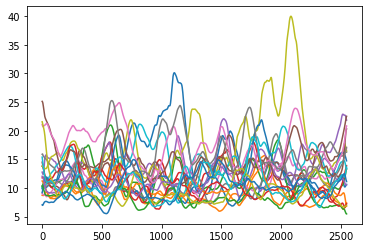

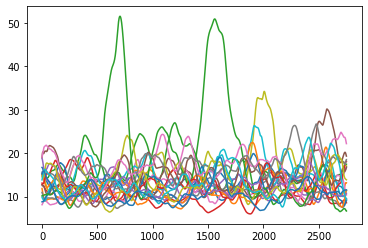

In [14]:
ARED_training_losses_dict = get_losses(timeseries_dict_train,model=model)
ARED_testing_losses_dict = get_losses(timeseries_dict_test,model)

In [16]:
train_loss_vals = []
for veh_id in veh_ids:
    train_loss_vals.append(ARED_training_losses_dict[veh_id])
    
train_loss_vals = np.array(train_loss_vals)
train_loss_vals = train_loss_vals.T


test_loss_vals = []
for veh_id in veh_ids:
    test_loss_vals.append(ARED_testing_losses_dict[veh_id])
    
test_loss_vals = np.array(test_loss_vals)
test_loss_vals = test_loss_vals.T

Saved figure.


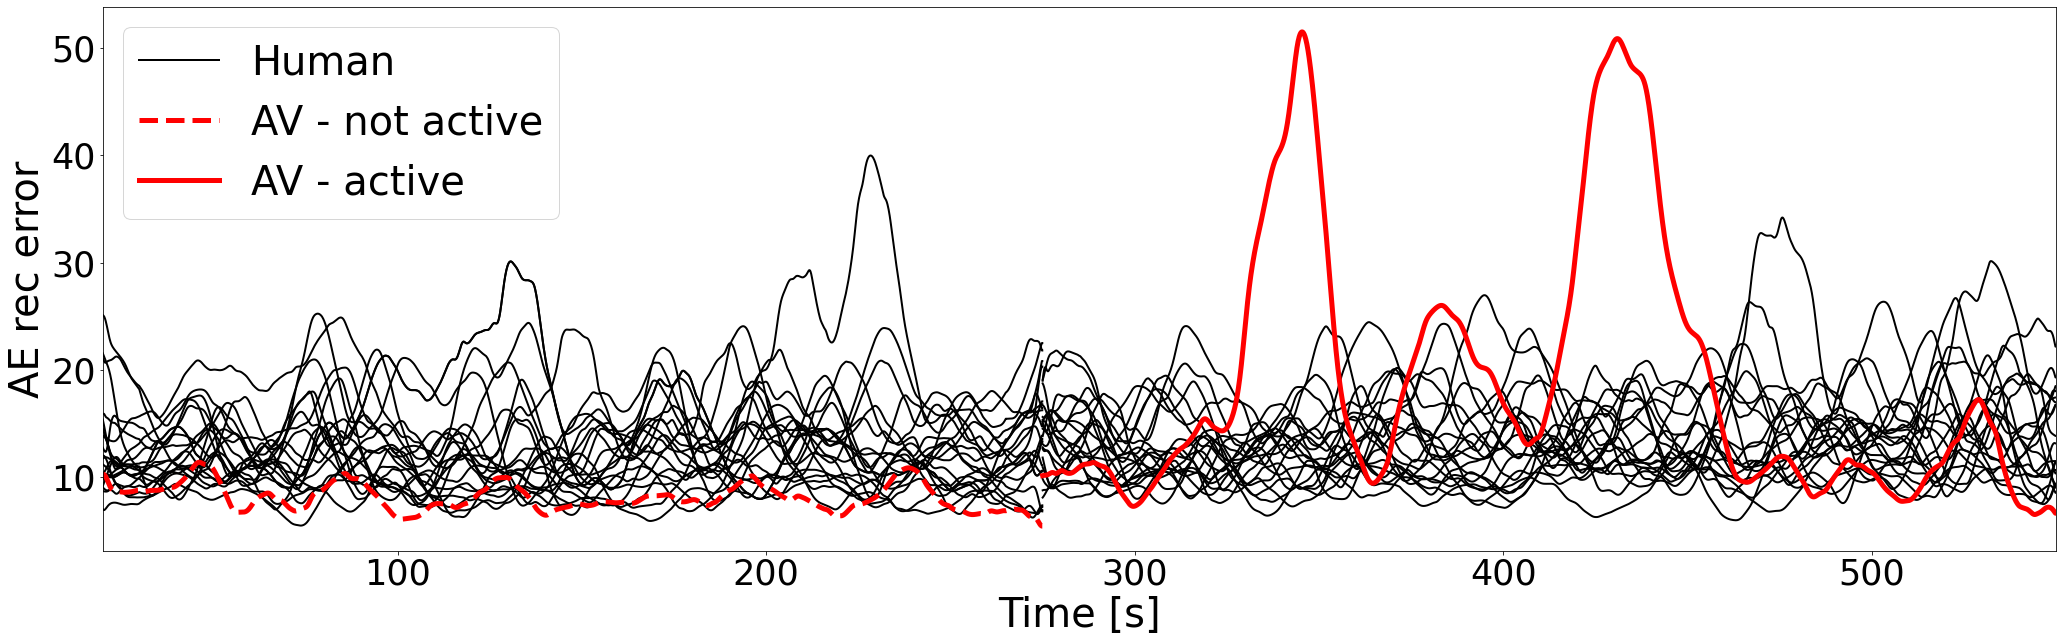

In [19]:


HV_train_rec_errors = np.concatenate((train_loss_vals[:,0:12],train_loss_vals[:,13:]),axis=1)
HV_train_T_vals = np.concatenate((T_train_resampled[:,0:12],T_train_resampled[:,13:]),axis=1)

AV_train_rec_errors = train_loss_vals[:,12]
AV_train_T_vals = T_train_resampled[:,12]


HV_test_rec_errors = np.concatenate((test_loss_vals[:,0:12],test_loss_vals[:,13:]),axis=1)
HV_test_T_vals = np.concatenate((T_test_resampled[:,0:12],T_test_resampled[:,13:]),axis=1)

AV_test_rec_errors = test_loss_vals[:,12]
AV_test_T_vals = T_test_resampled[:,12]

plt.figure(figsize=FIGURE_SIZE)

HV_linewidth=2.0
AV_linewidth=5.0

plt.plot(HV_train_T_vals,HV_train_rec_errors,'k',linewidth=HV_linewidth)
plt.plot(HV_train_T_vals[:,0],HV_train_rec_errors[:,0],'k',linewidth=HV_linewidth,label='Human')
plt.plot(AV_train_T_vals,AV_train_rec_errors,'r--',linewidth=AV_linewidth,label='AV - not active')

plt.plot(HV_test_T_vals,HV_test_rec_errors,'k',linewidth=HV_linewidth)
plt.plot(AV_test_T_vals,AV_test_rec_errors,'r',linewidth=AV_linewidth,label='AV - active')

plt.ylabel('AE rec error',fontsize=LABEL_FONTSIZE)
plt.xlabel('Time [s]',fontsize=LABEL_FONTSIZE)
plt.yticks(fontsize=TICK_FONTSIZE)
plt.xticks(fontsize=TICK_FONTSIZE)
plt.legend(fontsize=LABEL_FONTSIZE)
plt.xlim([HV_train_T_vals[0,0],HV_test_T_vals[-1,0]])

plt.savefig("ARED_RE_timeseries.png",bbox_inches='tight')

print('Saved figure.')